<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


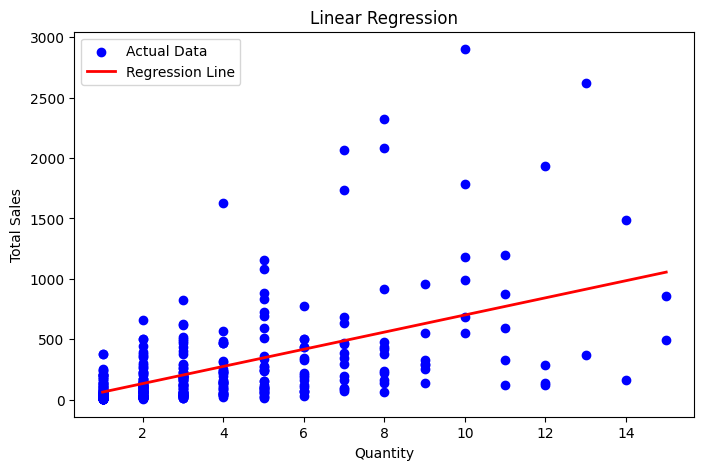

Slope (Coefficient): 70.94403696508286
Intercept: -7.925997519822033

Regression Equation:
Total Sales = 70.94 × Quantity + -7.93
Mean Absolute Error (MAE): 172.1850632424534
Mean Squared Error (MSE): 93666.98241389409
R² Score: 0.3062786707520827
   Quantity  Predicted Total Sales
0         5             346.794187
1        10             701.514372
2        15            1056.234557
========== Model Performance ==========
Mean Absolute Error (MAE): 172.19
Mean Squared Error (MSE): 93666.98
R² Score: 0.3063

Performance: Poor Model
Reason: The model does not fit the data well and cannot accurately predict Total Sales.


In [15]:
# ==========================================
# 1. Dataset Loading and Exploration
# ==========================================

import pandas as pd

# Load the dataset
df = pd.read_csv('/content/global_ecommerce_sales.csv')

# Display the first 5 rows
df.head()

# Display dataset information
df.info()

# Display statistical summary
df.describe()
# ==========================================
# 2. Selecting Features & Target
# ==========================================

X = df[['Quantity']]
y = df['Total_Sales']
# ==========================================
# 3. Splitting Into Training and Testing Phase
# ==========================================

from sklearn.model_selection import train_test_split

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# ==========================================
# 4. Training & Predicting
# ==========================================

from sklearn.linear_model import LinearRegression

# Training the model & predicting

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# ==========================================
# 5. Displaying Actual vs Predicted Values
# ==========================================

comparison = pd.DataFrame({
    "Actual Total Sales": y_test.values,
    "Predicted Total Sales": y_pred
})

comparison.head(10)
# ==========================================
# 6. Plotting the Regression Line
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Sort values for a smooth regression line
sorted_index = np.argsort(X_test.values.flatten())

X_test_sorted = X_test.values.flatten()[sorted_index]
y_test_sorted = y_test.values[sorted_index]
y_pred_sorted = y_pred[sorted_index]

# Plotting
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')

plt.title("Linear Regression")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.legend()

plt.show()
# ==========================================
# 7. Displaying Slope, Intercept & Equation
# ==========================================

# Display slope and intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# Display regression equation
print("\nRegression Equation:")
print(f"Total Sales = {model.coef_[0]:.2f} × Quantity + {model.intercept_:.2f}")
# ==========================================
# 8. Evaluation using MAE, MSE & R² Score
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)
# ==========================================
# 9. Predicting for New Values
# ==========================================

import pandas as pd

# New Quantity values
new_data = pd.DataFrame({
    'Quantity': [5, 10, 15]
})

# Predict Total Sales
new_predictions = model.predict(new_data)

# Display predictions
prediction_df = pd.DataFrame({
    'Quantity': new_data['Quantity'],
    'Predicted Total Sales': new_predictions
})

print(prediction_df)
# ==========================================
# 10. Comparing Model Performance
# ==========================================

# Display the evaluation metrics obtained from the trained model
print("========== Model Performance ==========")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Compare the model performance based on the R² Score
if r2 >= 0.90:
    print("\nPerformance: Excellent Model")
    print("Reason: The model explains most of the variation in Total Sales and provides highly accurate predictions.")
elif r2 >= 0.75:
    print("\nPerformance: Good Model")
    print("Reason: The model predicts Total Sales well, but there is still some prediction error.")
elif r2 >= 0.50:
    print("\nPerformance: Average Model")
    print("Reason: The model captures part of the relationship, but its predictions can be improved.")
else:
    print("\nPerformance: Poor Model")
    print("Reason: The model does not fit the data well and cannot accurately predict Total Sales.")